# Phase 6.1 — Solar Panel ↔ Rooftop Spatial Matching

**Project:** Solar Rooftop Detection & Potential Estimation — Surat

## Goal
For every YOLO-detected solar panel, determine which SAM-derived rooftop/building footprint it belongs to while preserving the original geographic geometry needed for the final Leaflet map.

### Inputs
- `footprints.geojson` — Phase 4 rooftop footprints
- `solar_panels.geojson` — Phase 5.4 georeferenced YOLO detections

### Outputs
- `phase6_panel_rooftop_matches.geojson`
- `phase6_rooftops_with_solar_attributes.geojson`
- `phase6_rooftop_summary.csv`

**Important:** This notebook establishes trustworthy panel → rooftop associations. Capacity/generation calculations come later.


In [ ]:
!pip -q install geopandas shapely pyogrio rtree matplotlib pandas

import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from google.colab import files

print("Environment ready.")


Environment ready.


## 1. Upload Phase 6 inputs

Upload the actual `footprints.geojson` and `solar_panels.geojson` produced by the previous phases.


In [ ]:
uploaded = files.upload()
print("Uploaded:")
for name in uploaded:
    print(" -", name)

geojsons = [n for n in uploaded if n.lower().endswith((".geojson", ".json"))]
if len(geojsons) < 2:
    raise ValueError("Please upload both footprints.geojson and solar_panels.geojson.")

print("GeoJSON candidates:", geojsons)


Saving solar_panels.geojson to solar_panels.geojson
Saving footprints.geojson to footprints.geojson
Uploaded:
 - solar_panels.geojson
 - footprints.geojson
GeoJSON candidates: ['solar_panels.geojson', 'footprints.geojson']


## 2. Load and inspect both layers

We inspect CRS, geometry types, feature counts, and properties before making any assumptions.


In [ ]:
def inspect_geojson(path):
    g = gpd.read_file(path)
    print(f"\n===== {path} =====")
    print("Features:", len(g))
    print("CRS:", g.crs)
    print("Geometry types:", g.geometry.geom_type.value_counts().to_dict())
    print("Columns:", list(g.columns))
    display(g.head(3))
    return g

for path in geojsons:
    inspect_geojson(path)



===== solar_panels.geojson =====
Features: 372
CRS: EPSG:4326
Geometry types: {'Polygon': 372}
Columns: ['panel_id', 'source_tile', 'confidence', 'class_id', 'x1_px', 'y1_px', 'x2_px', 'y2_px', 'geometry']


,panel_id,source_tile,confidence,class_id,x1_px,y1_px,x2_px,y2_px,geometry
0,tile_17-P0001,tile_17,0.902302,1,902.586182,769.677002,927.390259,790.917847,"POLYGON ((72.77803 21.16202, 72.77807 21.16202..."
1,tile_17-P0002,tile_17,0.894224,1,1436.280640,915.628723,1467.566528,933.817261,"POLYGON ((72.77892 21.1616, 72.77898 21.1616, ..."
2,tile_17-P0003,tile_17,0.860912,1,3.224022,84.383728,41.878319,115.822479,"POLYGON ((72.77652 21.16397, 72.77659 21.16397..."



===== footprints.geojson =====
Features: 1132
CRS: EPSG:4326
Geometry types: {'Polygon': 1132}
Columns: ['building_id', 'source_tile', 'geometry']


,building_id,source_tile,geometry
0,SRT-0001,tile_17,"POLYGON ((72.77895 21.16232, 72.77895 21.16231..."
1,SRT-0002,tile_17,"POLYGON ((72.77742 21.16358, 72.77742 21.16357..."
2,SRT-0003,tile_17,"POLYGON ((72.77885 21.16214, 72.77885 21.16214..."


## 3. Select the rooftop and panel layers

Automatic selection uses filenames. If it selects incorrectly, change the two variables manually.


In [ ]:
roof_candidates = sorted(
    geojsons,
    key=lambda p: sum(k in os.path.basename(p).lower() for k in ["footprint","roof","building"]),
    reverse=True
)
panel_candidates = sorted(
    geojsons,
    key=lambda p: sum(k in os.path.basename(p).lower() for k in ["solar","panel","detection"]),
    reverse=True
)

roof_path = roof_candidates[0]
panel_path = panel_candidates[0]

if roof_path == panel_path:
    raise ValueError("Automatic selection was ambiguous. Set roof_path and panel_path manually.")

print("Rooftop layer:", roof_path)
print("Panel layer:", panel_path)

roofs = gpd.read_file(roof_path)
panels = gpd.read_file(panel_path)


Rooftop layer: footprints.geojson
Panel layer: solar_panels.geojson


## 4. CRS and geometry sanity check

The master/map geometry is kept in EPSG:4326. A projected copy is created later for metric intersection/area calculations.


In [ ]:
print("Roof CRS :", roofs.crs)
print("Panel CRS:", panels.crs)

if roofs.crs is None or panels.crs is None:
    raise ValueError("One or both layers have no CRS. Fix georeferencing before matching.")

roofs = roofs[roofs.geometry.notna() & ~roofs.geometry.is_empty].copy().reset_index(drop=True)
panels = panels[panels.geometry.notna() & ~panels.geometry.is_empty].copy().reset_index(drop=True)

roofs = roofs.to_crs("EPSG:4326")
panels = panels.to_crs("EPSG:4326")

roofs["roof_id"] = [f"ROOF_{i:05d}" for i in range(len(roofs))]
panels["panel_id"] = [f"PANEL_{i:05d}" for i in range(len(panels))]

print("Clean roofs :", len(roofs))
print("Clean panels:", len(panels))
print("Both master layers are EPSG:4326.")


Roof CRS : EPSG:4326
Panel CRS: EPSG:4326
Clean roofs : 1132
Clean panels: 372
Both master layers are EPSG:4326.


## 5. Geographic overlap check

**STOP if this plot is badly offset.** The two layers must occupy the same physical area before matching.


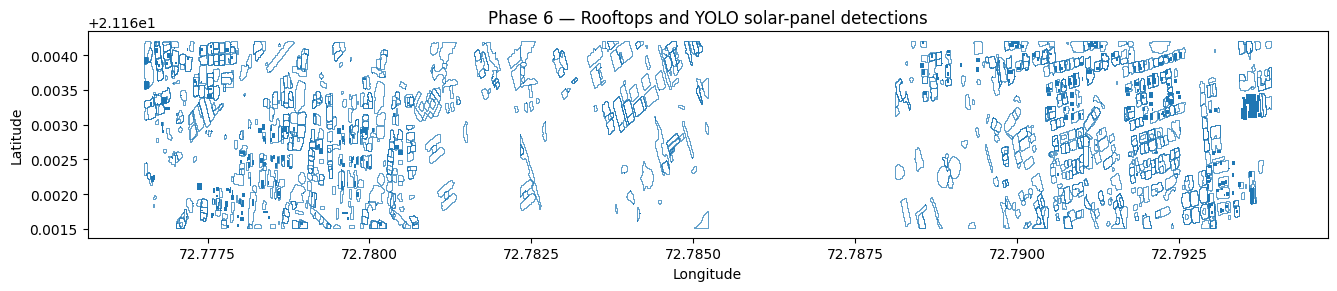

In [ ]:
fig, ax = plt.subplots(figsize=(16, 15))
roofs.boundary.plot(ax=ax, linewidth=0.5)
panels.plot(ax=ax, markersize=8)
ax.set_title("Rooftops and YOLO solar-panel detections")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()


## 6. Create a metric working CRS

Surat is in UTM Zone 43N, so EPSG:32643 is used temporarily for intersection and area calculations. EPSG:4326 remains the map-facing CRS.


In [ ]:
WORK_CRS = "EPSG:32643"

roofs_m = roofs.to_crs(WORK_CRS).copy()
panels_m = panels.to_crs(WORK_CRS).copy()

roofs_m["roof_area_m2"] = roofs_m.geometry.area
panels_m["panel_area_m2"] = panels_m.geometry.area

print("Working CRS:", WORK_CRS)
print("Roof area range:", roofs_m["roof_area_m2"].min(), "to", roofs_m["roof_area_m2"].max(), "m²")
print("Panel area range:", panels_m["panel_area_m2"].min(), "to", panels_m["panel_area_m2"].max(), "m²")


Working CRS: EPSG:32643
Roof area range: 0.10956060318451888 to 643.6039807961972 m²
Panel area range: 3.6794584469650196 to 239.0885219171958 m²


## 7. Generate spatial candidates and score overlap

For each panel, candidate rooftops are found with the spatial index. The actual intersection is then calculated.

`panel_overlap_pct` = percentage of the panel geometry lying inside the rooftop.

This is more robust than assigning by centroid alone.


In [ ]:
from shapely.geometry import Point

roof_sindex = roofs_m.sindex
records = []

for p_idx, p_row in panels_m.iterrows():
    p_geom = p_row.geometry
    p_area = p_row["panel_area_m2"]
    p_centroid = p_geom.centroid  # NEW: use the panel's center point, not full-area overlap

    candidate_idx = list(roof_sindex.query(p_geom, predicate="intersects"))
    candidates = []

    for r_idx in candidate_idx:
        r_geom = roofs_m.iloc[r_idx].geometry
        inter_area = p_geom.intersection(r_geom).area
        panel_overlap = inter_area / p_area if p_area > 0 else 0.0
        roof_coverage = inter_area / r_geom.area if r_geom.area > 0 else 0.0
        centroid_inside = r_geom.contains(p_centroid)  # NEW: does the roof contain the panel's center?
        candidates.append((r_idx, inter_area, panel_overlap, roof_coverage, centroid_inside))

    # NEW: prefer candidates where the centroid actually falls inside, then sort by overlap
    candidates.sort(key=lambda x: (x[4], x[2]), reverse=True)

    if candidates:
        best_r, inter_area, panel_overlap, roof_coverage, centroid_inside = candidates[0]
        second = candidates[1][2] if len(candidates) > 1 else 0.0
        records.append({
            "panel_idx": p_idx, "roof_idx": best_r, "intersection_m2": inter_area,
            "panel_overlap_pct": panel_overlap * 100, "roof_coverage_pct": roof_coverage * 100,
            "second_best_overlap_pct": second * 100, "candidate_count": len(candidates),
            "centroid_inside": centroid_inside
        })
    else:
        records.append({
            "panel_idx": p_idx, "roof_idx": None, "intersection_m2": 0.0,
            "panel_overlap_pct": 0.0, "roof_coverage_pct": 0.0,
            "second_best_overlap_pct": 0.0, "candidate_count": 0, "centroid_inside": False
        })

matches = pd.DataFrame(records)
print("Panels evaluated:", len(matches))
print("Panels with centroid inside a rooftop:", matches["centroid_inside"].sum())

Panels evaluated: 372
Panels with centroid inside a rooftop: 244


## 8. Conservative matching rules

Initial rules:
- **≥ 50% panel overlap** → accepted
- **< 50%** → unmatched
- If two rooftops are both plausible and close in score → ambiguous

These are intentionally conservative. We will tune them only after visual inspection.


In [ ]:
MIN_PANEL_OVERLAP = 20.0   # relaxed from 50.0
AMBIGUOUS_MIN = 15.0
AMBIGUOUS_MARGIN = 8.0

def classify(row):
    if pd.isna(row["roof_idx"]):
        return "unmatched"

    # NEW: centroid-inside is a strong, forgiving signal on its own
    if row["centroid_inside"]:
        best = row["panel_overlap_pct"]
        second = row["second_best_overlap_pct"]
        if second >= AMBIGUOUS_MIN and (best - second) < AMBIGUOUS_MARGIN:
            return "ambiguous"
        return "matched"

    # fallback to relaxed area-overlap rule
    if row["panel_overlap_pct"] < MIN_PANEL_OVERLAP:
        return "unmatched"
    return "matched"

matches["status"] = matches.apply(classify, axis=1)
print(matches["status"].value_counts(dropna=False))

status
matched      130
unmatched    127
ambiguous    115
Name: count, dtype: int64


## 9. Attach IDs and YOLO confidence where available


In [ ]:
matches["panel_id"] = matches["panel_idx"].map(panels_m["panel_id"])
matches["roof_id"] = matches["roof_idx"].map(roofs_m["roof_id"])
matches["panel_area_m2"] = matches["panel_idx"].map(panels_m["panel_area_m2"])
matches["roof_area_m2"] = matches["roof_idx"].map(roofs_m["roof_area_m2"])

conf_col = next((c for c in ["confidence", "conf", "score"] if c in panels.columns), None)

if conf_col:
    matches["yolo_confidence"] = matches["panel_idx"].map(panels[conf_col])
    print("YOLO confidence column:", conf_col)
else:
    matches["yolo_confidence"] = np.nan
    print("No YOLO confidence property found.")

display(matches[[
    "panel_id","roof_id","panel_area_m2",
    "panel_overlap_pct","status","yolo_confidence"
]].head(10))


YOLO confidence column: confidence


,panel_id,roof_id,panel_area_m2,panel_overlap_pct,status,yolo_confidence
0,PANEL_00000,NaN,28.861689,0.000000,unmatched,0.902302
1,PANEL_00001,ROOF_00286,31.172661,100.000000,ambiguous,0.894224
2,PANEL_00002,ROOF_00229,66.571012,78.495399,ambiguous,0.860912
3,PANEL_00003,ROOF_00136,82.444976,94.256888,ambiguous,0.856944
4,PANEL_00004,NaN,17.616719,0.000000,unmatched,0.830962
5,PANEL_00005,ROOF_00185,38.388786,99.795775,ambiguous,0.812317
6,PANEL_00006,NaN,37.583371,0.000000,unmatched,0.802382
7,PANEL_00007,ROOF_00234,21.773966,98.028487,ambiguous,0.800913
8,PANEL_00008,ROOF_00120,25.109896,98.956441,matched,0.787082
9,PANEL_00009,NaN,10.110624,0.000000,unmatched,0.785885


## 10. Diagnostic visualization

Inspect this carefully. Accepted panels should physically sit on the correct rooftop polygons.


/tmp/ipykernel_1643/2251496830.py:14: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/tmp/ipykernel_1643/2251496830.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


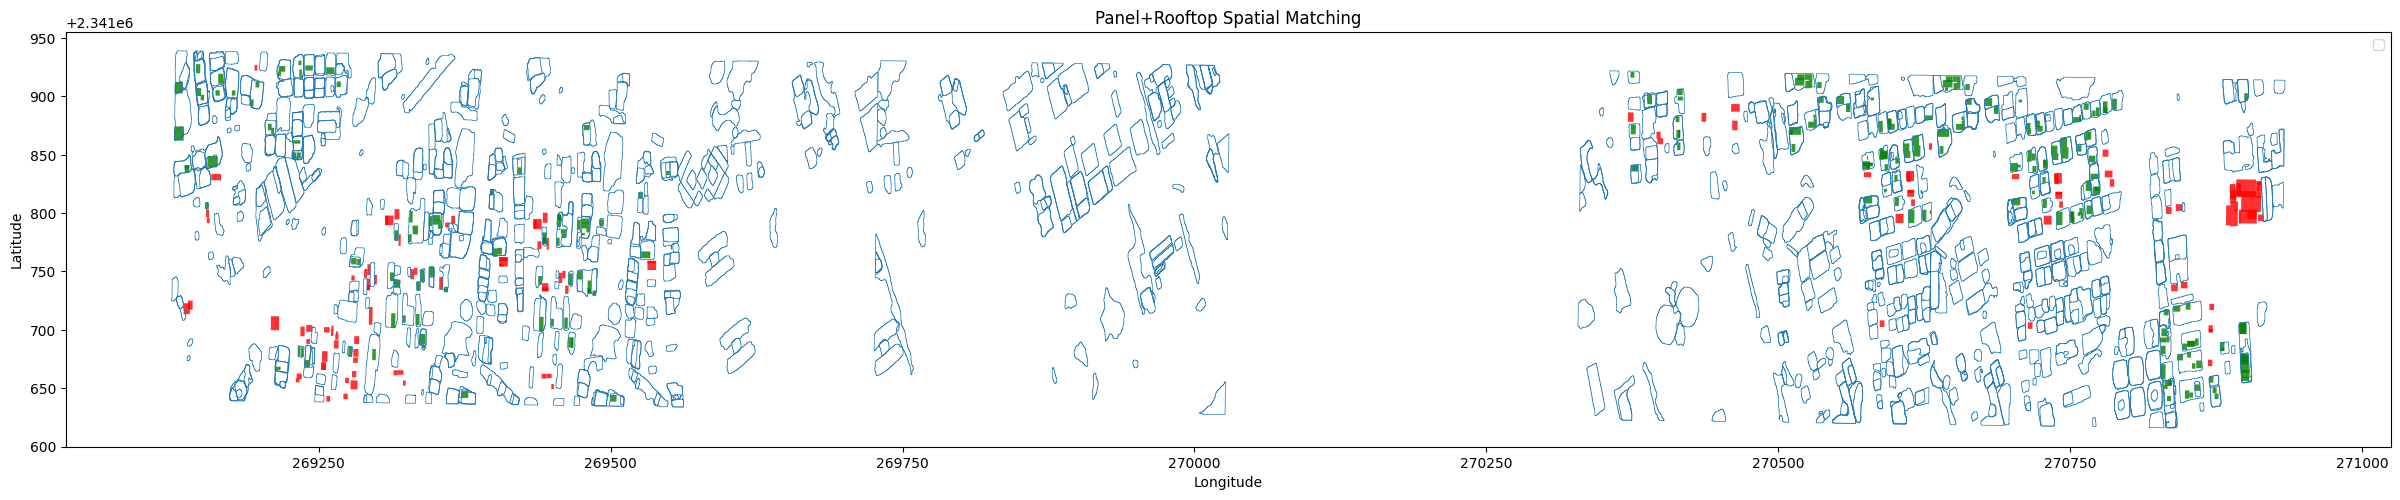

In [ ]:
status_colors = {"matched": "green", "ambiguous": "green", "unmatched": "red"}

fig, ax = plt.subplots(figsize=(30, 10))
roofs_m.boundary.plot(ax=ax, linewidth=0.5)

for status, color in status_colors.items():
    ids = matches.index[matches["status"] == status].tolist()
    if ids:
        panels_m.iloc[ids].plot(
            ax=ax, color=color, alpha=0.8,
            markersize=12, label=status
        )

ax.legend()
ax.set_title ("Panel+Rooftop Spatial Matching")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()


## 11. Build panel-level GeoJSON

The original panel geometry remains in EPSG:4326. Matching attributes are added so this layer can later be used directly by Leaflet.


In [ ]:
panel_out = panels.copy()

for col in [
    "panel_idx","roof_idx","roof_id","intersection_m2",
    "panel_overlap_pct","roof_coverage_pct",
    "second_best_overlap_pct","candidate_count","status",
    "panel_area_m2","roof_area_m2","yolo_confidence"
]:
    if col in matches.columns:
        panel_out[col] = matches[col].values

panel_out["match_note"] = panel_out["status"].map({
    "matched": "Accepted rooftop association",
    "ambiguous": "Needs visual review before downstream analysis",
    "unmatched": "No sufficiently strong rooftop overlap"
})

out_geojson = "phase6_panel_rooftop_matches.geojson"
panel_out.to_file(out_geojson, driver="GeoJSON")

print("Saved:", out_geojson)


Saved: phase6_panel_rooftop_matches.geojson


## 12. Create rooftop-level solar summary

Only **accepted** matches are aggregated. Ambiguous/unmatched detections are not allowed to contaminate rooftop totals.


In [ ]:
accepted = matches[matches["status"] == "matched"].copy()

if len(accepted):
    summary = accepted.groupby("roof_id").agg(
        panel_count=("panel_id", "count"),
        panel_area_m2=("panel_area_m2", "sum"),
        mean_panel_overlap_pct=("panel_overlap_pct", "mean"),
        mean_yolo_confidence=("yolo_confidence", "mean")
    ).reset_index()
else:
    summary = pd.DataFrame(columns=[
        "roof_id","panel_count","panel_area_m2",
        "mean_panel_overlap_pct","mean_yolo_confidence"
    ])

roof_base = roofs[["roof_id","geometry"]].copy()
roof_base = roof_base.merge(
    roofs_m[["roof_id","roof_area_m2"]],
    on="roof_id", how="left"
)
roof_base = roof_base.merge(summary, on="roof_id", how="left")

roof_base["panel_count"] = roof_base["panel_count"].fillna(0).astype(int)
roof_base["panel_area_m2"] = roof_base["panel_area_m2"].fillna(0.0)
roof_base["solar_detected"] = roof_base["panel_count"] > 0

roof_base["panel_coverage_pct"] = np.where(
    roof_base["roof_area_m2"] > 0,
    100 * roof_base["panel_area_m2"] / roof_base["roof_area_m2"],
    0
)

roof_base.to_csv("phase6_rooftop_summary.csv", index=False)
display(roof_base.drop(columns="geometry").head(10))


,roof_id,roof_area_m2,panel_count,panel_area_m2,mean_panel_overlap_pct,mean_yolo_confidence,solar_detected,panel_coverage_pct
0,ROOF_00000,152.727938,0,0.0,NaN,NaN,False,0.0
1,ROOF_00001,154.863375,0,0.0,NaN,NaN,False,0.0
2,ROOF_00002,517.950127,0,0.0,NaN,NaN,False,0.0
3,ROOF_00003,626.135833,0,0.0,NaN,NaN,False,0.0
4,ROOF_00004,187.895756,0,0.0,NaN,NaN,False,0.0
5,ROOF_00005,151.302002,0,0.0,NaN,NaN,False,0.0
6,ROOF_00006,207.673552,0,0.0,NaN,NaN,False,0.0
7,ROOF_00007,53.903685,0,0.0,NaN,NaN,False,0.0
8,ROOF_00008,174.748415,0,0.0,NaN,NaN,False,0.0
9,ROOF_00009,157.273037,0,0.0,NaN,NaN,False,0.0


In [ ]:
print(f'Before filtering: {len(roof_base)} rooftops')
roof_base = roof_base[roof_base['roof_area_m2'] >= 5.0].reset_index(drop=True)
print(f'After filtering: {len(roof_base)} rooftops (removed tiny SAM noise fragments)')

Before filtering: 1132 rooftops
After filtering: 1131 rooftops (removed tiny SAM noise fragments)


## 13. Export rooftop GeoJSON for the future Leaflet map


In [ ]:
rooftop_geojson = "phase6_rooftops_with_solar_attributes.geojson"
roof_base.to_file(rooftop_geojson, driver="GeoJSON")

print("Saved:", rooftop_geojson)


Saved: phase6_rooftops_with_solar_attributes.geojson


## 14. Final Phase 6 report and checkpoint


In [ ]:
print("================ PHASE 6 REPORT ================")
print("Rooftops:", len(roofs))
print("Panels:", len(panels))
print("Matched panels:", int((matches.status == "matched").sum()))
print("Ambiguous panels:", int((matches.status == "ambiguous").sum()))
print("Unmatched panels:", int((matches.status == "unmatched").sum()))
print("Rooftops with solar:", int(roof_base.solar_detected.sum()))

if len(accepted):
    print("Mean accepted panel overlap:",
          round(accepted.panel_overlap_pct.mean(), 2), "%")
else:
    print("Mean accepted panel overlap: N/A")

print("=================================================")
print("\nCHECKPOINT:")
print("1. Inspect the diagnostic plot.")
print("2. Verify accepted panels sit on correct rooftops.")
print("3. Do not calculate capacity until matching is trustworthy.")


================ PHASE 6 REPORT ================
Rooftops: 1132
Panels: 372
Matched panels: 130
Ambiguous panels: 115
Unmatched panels: 127
Rooftops with solar: 71
Mean accepted panel overlap: 96.27 %

CHECKPOINT:
1. Inspect the diagnostic plot.
2. Verify accepted panels sit on correct rooftops.
3. Do not calculate capacity until matching is trustworthy.


## 15. Download the Phase 6 outputs


In [ ]:
for path in [
    "phase6_panel_rooftop_matches.geojson",
    "phase6_rooftops_with_solar_attributes.geojson",
    "phase6_rooftop_summary.csv"
]:
    if os.path.exists(path):
        files.download(path)

print("Phase 6.1 outputs ready.")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Phase 6.1 outputs ready.


### **POTENTIAL CALC**

In [ ]:
# Source: NITI Aayog ICED, https://iced.niti.gov.in/energy/fuel-sources/solar/irradiance
# 15-year average (2009-2023), Surat district, Gujarat — kWh/m² per month
MONTHLY_INSOLATION_KWH_M2 = {
    1: 123.51,  # Jan
    2: 138.46,  # Feb
    3: 179.58,  # Mar
    4: 191.17,  # Apr
    5: 200.20,  # May
    6: 155.75,  # Jun
    7: 135.63,  # Jul
    8: 168.11,  # Aug
    9: 149.68,  # Sep
    10: 153.62, # Oct
    11: 123.61, # Nov
    12: 115.54  # Dec
}

MONTH_NAMES = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

POWER_DENSITY_KWP_PER_M2 = 0.1   # 1 kWp per 10 m² — standard Indian rooftop solar rule of thumb
PERFORMANCE_RATIO = 0.75

print('Insolation table loaded:', MONTHLY_INSOLATION_KWH_M2)

Insolation table loaded: {1: 123.51, 2: 138.46, 3: 179.58, 4: 191.17, 5: 200.2, 6: 155.75, 7: 135.63, 8: 168.11, 9: 149.68, 10: 153.62, 11: 123.61, 12: 115.54}


In [ ]:
import pandas as pd

roof_base['capacity_kwp'] = roof_base['roof_area_m2'] * POWER_DENSITY_KWP_PER_M2

# Compute monthly energy potential for ALL 12 months per rooftop, only for roofs WITHOUT solar
def compute_monthly_energy(capacity_kwp):
    return {
        MONTH_NAMES[m]: round(capacity_kwp * insol * PERFORMANCE_RATIO, 1)
        for m, insol in MONTHLY_INSOLATION_KWH_M2.items()
    }

roof_base['monthly_energy_kwh'] = roof_base.apply(
    lambda row: compute_monthly_energy(row['capacity_kwp']) if not row['solar_detected'] else None,
    axis=1
)

print(roof_base[['roof_id', 'roof_area_m2', 'capacity_kwp', 'solar_detected']].head())

      roof_id  roof_area_m2  capacity_kwp  solar_detected
0  ROOF_00000    152.727938     15.272794           False
1  ROOF_00001    154.863375     15.486337           False
2  ROOF_00002    517.950127     51.795013           False
3  ROOF_00003    626.135833     62.613583           False
4  ROOF_00004    187.895756     18.789576           False


In [ ]:
import json

final_results = []
for _, row in roof_base.iterrows():
    final_results.append({
        'id': row['roof_id'],
        'geometry': row['geometry'].__geo_interface__,
        'has_panel': bool(row['solar_detected']),
        'area_m2': round(row['roof_area_m2'], 1),
        'capacity_kwp': round(row['capacity_kwp'], 2) if not row['solar_detected'] else None,
        'monthly_energy_kwh': row['monthly_energy_kwh']  # full 12-month dict, or None if has panel
    })

with open('rooftop_calcresults.json', 'w') as f:
    json.dump(final_results, f, indent=2)

print(f'Saved {len(final_results)} rooftops to rooftop_results.json')

from google.colab import files
files.download('rooftop_calcresults.json')

Saved 1131 rooftops to rooftop_results.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>